# Pràctica Final d’Aprenentatge Supervisat  
## Predicció de popularitat musical amb optimització coarse-to-fine i Stacking

Treballarem amb un dataset de característiques d’àudio de cançons i la variable objectiu `popularity`. [Song Popularity Dataset (Kaggle)](https://www.kaggle.com/datasets/yasserh/song-popularity-dataset)


L’objectiu és construir, optimitzar i comparar diversos models de regressió mitjançant una estratègia de cerca jeràrquica (coarse-to-fine), i finalment crear un model ensemble amb Stacking.

---

# Objectius

S’avaluarà si ets capaç de:

- Analitzar críticament un dataset real
- Detectar característiques no rellevants
- Aplicar preprocessament evitant data leakage
- Implementar una estratègia de cerca coarse-to-fine
- Comparar models amb criteri tècnic
- Construir i interpretar un model ensemble

---

# Fase 1 — Anàlisi i preparació

1. Carrega el dataset.
2. Analitza:
   - dimensions
   - tipus de dades
   - valors nuls
3. Defineix:
   - `y` (variable objectiu)
   - `X` (predictors)
4. Detecta si hi ha alguna característica que no sigui adequada per a la predicció.
5. Justifica qualsevol eliminació.

No totes les variables són útils per predir popularitat.

---

# Fase 2 — Divisió i preprocessament

- Divideix en train/test amb `random_state` fix.
- Implementa el preprocessament necessari.
- Obligatori l’ús de `Pipeline`.

Penalització si es detecta fuga d’informació.

---

# Fase 3 — Optimització d’hiperparàmetres (Coarse-to-Fine Search)

No es permet una única cerca directa quan hi hagi hiperparàmetres en escala logarítmica.

Quan un hiperparàmetre pugui variar en diversos ordres de magnitud (`gamma`, `C`, `alpha`, etc.), hauràs d’aplicar una estratègia en fases:

## Fase A — Cerca coarse (exploració d’ordres de magnitud)

- Provar valors separats per diversos ordres de magnitud.
- Objectiu: identificar la regió prometedora.
- No ha de ser exhaustiva.

Exemple conceptual:
10^-6, 10^-3, 10^0, 10^3, 10^6

## Fase B — Cerca refinada

- Restringir la cerca a l’interval detectat.
- Explorar amb més densitat dins d’aquesta regió.

Exemple conceptual:
10, 50, 100, 300, 500, 800, 1000

## Fase C — Ajust fi

- Cerca seqüencial fina al voltant del millor valor trobat.

Has d’explicar explícitament:

- Quina ha estat la cerca coarse
- Quins resultats has obtingut
- Com has decidit l’interval de la cerca refinada

---

# Models a entrenar i optimitzar

Cal entrenar i optimitzar amb `GridSearchCV`:

- `LinearRegression`
- `KernelRidge`
- `KNeighborsRegressor`
- `DecisionTreeRegressor`
- `RandomForestRegressor`
- `SVR`

**Només es poden utilitzar hiperparàmetres treballats a classe.**

Per a cada model:

1. Definir graella inicial.
2. Aplicar validació creuada.
3. Mostrar:
   - Millors hiperparàmetres
   - Score mitjà de validació
4. Aplicar estratègia coarse-to-fine quan correspongui.
5. Entrenar el model final amb tot el conjunt d’entrenament.

---

# Fase 4 — Avaluació en test

Per cada model optimitzat:

- MAE
- MSE
- RMSE

Construeix una taula comparativa final amb tots els models.

Analitza:

- Diferència entre score de validació i score de test
- Possibles indicis de sobreajustament

---

# Fase 5 — Ensemble amb Stacking

Construeix un `StackingRegressor` utilitzant:

- Com a base learners: els millors models optimitzats
- Com a meta-model: `LinearRegression`

Avalua el model final sobre el conjunt de test.

---

# Interpretació del model de Stacking

Analitza el meta-model lineal:

1. Mostra els coeficients associats a cada model base.
2. Respon:

   - Quin model base rep més pes?
   - Hi ha algun model amb pes molt baix?
   - Hi ha algun coeficient negatiu? Què podria significar?
   - L'stacking millora realment respecte al millor model individual?
   - El meta-model sembla confiar en un únic model o combina diversos?

3. Interpreta si hi ha complementarietat entre models.

---

# Fase final — Anàlisi crítica

1. Quin model generalitza millor?
2. Quin model mostra més variància?
3. El problema sembla principalment lineal o no lineal?
4. És realista predir la popularitat només amb característiques d’àudio?
5. Limitacions del dataset.

---

# Requisits d’entrega

El notebook ha de:

- Executar-se completament sense errors
- Incloure comentaris explicatius
- Justificar decisions tècniques
- Mostrar clarament les diferents fases de cerca
- No presentar fuga d’informació
- Estar estructurat i llegible


---

# Fase 1 — Anàlisi i preparació

1. Carrega el dataset.
2. Analitza:
   - dimensions
   - tipus de dades
   - valors nuls
3. Defineix:
   - `y` (variable objectiu)
   - `X` (predictors)
4. Detecta si hi ha alguna característica que no sigui adequada per a la predicció.
5. Justifica qualsevol eliminació.

No totes les variables són útils per predir popularitat.

---

In [11]:
import pandas as pd
import numpy as np

In [12]:
df = pd.read_csv("song_data.csv")
df

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,Boulevard of Broken Dreams,73,262333,0.005520,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,In The End,66,216933,0.010300,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,Seven Nation Army,76,231733,0.008170,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,By The Way,74,216933,0.026400,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,How You Remind Me,56,223826,0.000954,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18830,Let It Breathe,60,159645,0.893000,0.500,0.151,0.000065,11,0.1110,-16.107,1,0.0348,113.969,4,0.300
18831,Answers,60,205666,0.765000,0.495,0.161,0.000001,11,0.1050,-14.078,0,0.0301,94.286,4,0.265
18832,Sudden Love (Acoustic),23,182211,0.847000,0.719,0.325,0.000000,0,0.1250,-12.222,1,0.0355,130.534,4,0.286
18833,Gentle on My Mind,55,352280,0.945000,0.488,0.326,0.015700,3,0.1190,-12.020,1,0.0328,106.063,4,0.323


In [13]:
# Dimensions
# filas / columnas
df.shape

(18835, 15)

In [14]:
df.dtypes

song_name            object
song_popularity       int64
song_duration_ms      int64
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
key                   int64
liveness            float64
loudness            float64
audio_mode            int64
speechiness         float64
tempo               float64
time_signature        int64
audio_valence       float64
dtype: object

In [15]:
df.dropna()
df.isnull().sum() 

song_name           0
song_popularity     0
song_duration_ms    0
acousticness        0
danceability        0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
audio_mode          0
speechiness         0
tempo               0
time_signature      0
audio_valence       0
dtype: int64

In [16]:
X = df.drop(columns=["song_name","song_popularity"]) #eliminamos nombre, no aporta nada, solo ruido
y = df.song_popularity
X

,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,262333,0.005520,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,216933,0.010300,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,231733,0.008170,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,216933,0.026400,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,223826,0.000954,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18830,159645,0.893000,0.500,0.151,0.000065,11,0.1110,-16.107,1,0.0348,113.969,4,0.300
18831,205666,0.765000,0.495,0.161,0.000001,11,0.1050,-14.078,0,0.0301,94.286,4,0.265
18832,182211,0.847000,0.719,0.325,0.000000,0,0.1250,-12.222,1,0.0355,130.534,4,0.286
18833,352280,0.945000,0.488,0.326,0.015700,3,0.1190,-12.020,1,0.0328,106.063,4,0.323


---

# Fase 2 — Divisió i preprocessament

- Divideix en train/test amb `random_state` fix.
- Implementa el preprocessament necessari.
- Obligatori l’ús de `Pipeline`.

Penalització si es detecta fuga d’informació.

---

In [17]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder, FunctionTransformer, StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [18]:
X.keys()

Index(['song_duration_ms', 'acousticness', 'danceability', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'audio_mode',
       'speechiness', 'tempo', 'time_signature', 'audio_valence'],
      dtype='object')

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_transformer = Pipeline(steps=[
('numeric_imputer', SimpleImputer(strategy='mean')),
('scaler', RobustScaler())
]) 

# La key la he de transformar con oneHotEncoder ya que son caracteristicas como tal do re mi da no quiero 
# que aprenda patrones falsos como si es mas alto el numeor de la key mas popular, ya que no tiene mucho snetido 
# si las 11 son populares las 10 lo seran un poco menos y las 0 nada populares
categorical_transformer = Pipeline(steps=[
('encoder', OneHotEncoder()),
]) 

numeric_col =  ['song_duration_ms', 'acousticness', 'danceability', 'energy',
       'instrumentalness', 'liveness', 'loudness', 'audio_mode',
       'speechiness', 'tempo', 'time_signature', 'audio_valence', "key"]
#categorical_col = ["key"]# lo quito por el timpo que tarda el kernel ridge
categorical_col = []

preprocessor = ColumnTransformer(transformers=[
('numeric_transformer', numeric_transformer,numeric_col),
('categorical_transformer', categorical_transformer,categorical_col),
],
)

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
])

pipe.fit(X_train)
X_train_processed = pipe.transform(X_train)
X_test_processed = pipe.transform(X_test) 

raw_feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()

clean_names = [col.split('__')[-1] for col in raw_feature_names]

X_train = pd.DataFrame(X_train_processed, columns=clean_names, index=X_train.index)
X_test = pd.DataFrame(X_test_processed, columns=clean_names, index=X_test.index)

X_train.head()

,song_duration_ms,acousticness,danceability,energy,instrumentalness,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence,key
4501,-0.287803,1.130326,-1.460465,-1.355263,13.078346,0.476842,-1.802561,0.0,0.503075,1.335162,0.0,-0.071611,0.166667
12204,0.975629,-0.281704,0.809302,0.276316,-0.001906,-0.474497,0.593411,-1.0,1.125461,-0.286150,0.0,0.902813,0.833333
10675,-0.130166,-0.193233,-0.376744,0.128289,-0.004361,0.257964,0.381773,0.0,0.904059,1.337195,0.0,-0.503836,0.333333
11146,-2.161388,1.979950,0.102326,-1.532895,350.371579,0.015634,-1.655967,-1.0,-0.066421,0.673206,0.0,0.350384,0.833333
1664,0.507288,-0.330393,-1.413953,0.779605,-0.004361,0.734806,0.265761,0.0,0.468635,1.196923,0.0,-0.447570,0.166667


# Fase 3 — Optimització d’hiperparàmetres (Coarse-to-Fine Search)

No es permet una única cerca directa quan hi hagi hiperparàmetres en escala logarítmica.

Quan un hiperparàmetre pugui variar en diversos ordres de magnitud (`gamma`, `C`, `alpha`, etc.), hauràs d’aplicar una estratègia en fases:

## Fase A — Cerca coarse (exploració d’ordres de magnitud)

- Provar valors separats per diversos ordres de magnitud.
- Objectiu: identificar la regió prometedora.
- No ha de ser exhaustiva.

Exemple conceptual:
10^-6, 10^-3, 10^0, 10^3, 10^6

## Fase B — Cerca refinada

- Restringir la cerca a l’interval detectat.
- Explorar amb més densitat dins d’aquesta regió.

Exemple conceptual:
10, 50, 100, 300, 500, 800, 1000

## Fase C — Ajust fi

- Cerca seqüencial fina al voltant del millor valor trobat.

Has d’explicar explícitament:

- Quina ha estat la cerca coarse
- Quins resultats has obtingut
- Com has decidit l’interval de la cerca refinada

---

# Models a entrenar i optimitzar

Cal entrenar i optimitzar amb `GridSearchCV`:

- `LinearRegression`
- `KernelRidge`
- `KNeighborsRegressor`
- `DecisionTreeRegressor`
- `RandomForestRegressor`
- `SVR`

**Només es poden utilitzar hiperparàmetres treballats a classe.**

Per a cada model:

1. Definir graella inicial.
2. Aplicar validació creuada.
3. Mostrar:
   - Millors hiperparàmetres
   - Score mitjà de validació
4. Aplicar estratègia coarse-to-fine quan correspongui.
5. Entrenar el model final amb tot el conjunt d’entrenament.

---

## Linear Regresor

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [21]:
regressor = Pipeline(steps=[
    ('poly', PolynomialFeatures()),
    ('reg', LinearRegression())
])

parameters = {
    'poly__degree': [1, 2,3,4], #polinomis de fins a X grau. Mai poseu grau major que 4
    'poly__interaction_only': [True, False] #totes les combinacions o sols les interaccions
}


grid_search = GridSearchCV(
    estimator=regressor,
    param_grid=parameters,
    cv=3, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'poly__degree': [1, 2, ...], 'poly__interaction_only': [True, False]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,degree,2


In [22]:
grid_search.cv_results_['mean_fit_time']

array([ 0.02412645,  0.02426823,  0.15803925,  0.23105884,  0.81661248,
        1.34713244,  3.39991935, 13.23329584])

In [23]:
grid_search.cv_results_['mean_test_score']

array([-17.04658263, -17.04658263, -16.70957315, -16.6699251 ,
       -16.8599596 , -16.95422379, -19.1795931 , -25.94758609])

In [24]:
grid_search.best_params_

{'poly__degree': 2, 'poly__interaction_only': False}

In [25]:
grid_search.best_score_

np.float64(-16.66992509997279)

In [26]:
#Test
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred = grid_search.predict(X_test)

grid_search_linear_regresion=  grid_search

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')

MAE: 16.623683907758128
MSE: 442.87125614157424
RMSE: 21.04450655495572


## KernelRidge

In [34]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV

In [78]:
pipe = Pipeline(steps=[
    ('krr', KernelRidge()) 
])

# Rangos de parámetros
# Alpha: Regularización (Pequeño = complejo, Grande = simple)
alpha_range = np.logspace(-3, 2, 5) 
gamma_range = np.logspace(-3, 3, 5) # Gamma controla la "anchura" de la campana de Gauss

parameters = [
    #  Kernel Lineal (Como una Ridge Regression normal)
    {
        'krr__kernel': ['linear'],
        'krr__alpha': alpha_range
    },
    # Polinomios
    {
        'krr__kernel': ['poly'],
        'krr__alpha': alpha_range,
        'krr__degree': [2, 3], # Quitamos el 4 para la primera prueba
    },
    # RBF (más potente y flexible)
    {
        'krr__kernel': ['rbf'],
        'krr__alpha': alpha_range,
        'krr__gamma': gamma_range
    }
]

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    scoring='neg_root_mean_squared_error', 
    cv=3,        
    verbose=2,  
    n_jobs=-1
)

# Entrenamos solo con las primeras 3.000 o 5.000 canciones
# Esto hará que vuele en comparación con antes
grid_search.fit(X_train[:4000], y_train[:4000])
#grid_search.fit(X_train, y_train)


print(f"RMSE: {-grid_search.best_score_}") 
print(f"params: {grid_search.best_params_}")

Fitting 3 folds for each of 40 candidates, totalling 120 fits
RMSE: 21.622695279098494
params: {'krr__alpha': np.float64(0.31622776601683794), 'krr__gamma': np.float64(0.001), 'krr__kernel': 'rbf'}


In [79]:
#La cerca coarse ha consistit en una exploració inicial utilitzant un GridSearchCV amb un rang 
#d'hiperparàmetres molt ampli (utilitzant np.logspace de -6 a 6).
# Hacemos zoom alrededor del 0.316 entre 0.1 y 0.6
alpha = np.linspace(0.1, 0.6, 5) 

# Hacemos zoom alrededor del 0.001 entre 0.0005 y 0.005
gamma = np.linspace(0.0005, 0.005, 5)

In [80]:
parameters = [
    {
        'krr__kernel': ['rbf'], 
        'krr__alpha': alpha,
        'krr__gamma': gamma
    }
]

grid_fine = GridSearchCV(
    estimator=pipe, 
    param_grid=parameters,
    scoring='neg_root_mean_squared_error',
    cv=5, 
    n_jobs=-1,
    verbose=1
)

grid_fine.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


C:\Users\EIABD\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\EIABD\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\EIABD\miniconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\EIABD\miniconda3\Lib\site-packages\sklearn\pipeline.py", line 663, in fit
    self._final_estimator.

,estimator,Pipeline(step...rnelRidge())])
,param_grid,"[{'krr__alpha': array([0.1 ,...0.475, 0.6 ]), 'krr__gamma': array([0.0005...75, 0.005 ]), 'krr__kernel': ['rbf']}]"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(0.225)


In [81]:
print(f"RMSE: {-grid_search.best_score_}") 
print(f"params: {grid_search.best_params_}")

RMSE: 21.622695279098494
params: {'krr__alpha': np.float64(0.31622776601683794), 'krr__gamma': np.float64(0.001), 'krr__kernel': 'rbf'}


In [84]:
# Hacemos zoom alrededor del 0.31622 entre 0.2 y 0.4 hilando mas fino
alpha = np.linspace(0.2, 0.4, 10) 

# Hacemos zoom alrededor del 0.001 entre 0.0008 y 0.008
gamma = np.linspace(0.0008, 0.008, 10)
alpha

array([0.2       , 0.22222222, 0.24444444, 0.26666667, 0.28888889,
       0.31111111, 0.33333333, 0.35555556, 0.37777778, 0.4       ])

In [85]:
parameters = [
    {
        'krr__kernel': ['rbf'], 
        'krr__alpha': alpha,
        'krr__gamma': gamma
    }
]
grid_fine = GridSearchCV(
    estimator=pipe, 
    param_grid=parameters,
    scoring='neg_root_mean_squared_error',
    cv=5, 
    n_jobs=-1,
    verbose=1
)

grid_fine.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits



KeyboardInterrupt



In [ ]:
print(f"RMSE: {-grid_search.best_score_}") 
print(f"params: {grid_search.best_params_}")

In [40]:
#Test
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred = grid_search.predict(X_test)

grid_search_kernel_ridge = grid_search

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')

MAE: 16.83483641106277
MSE: 449.8808650733297
RMSE: 21.210395212568052


1. Quina ha estat la cerca coarse?
S'ha realitzat una primera exploració general per determinar l'ordre de magnitud dels hiperparàmetres. S'ha provat un gamma y un alpha en un rang denp.logspace(-3, 2, 5) , combinant-ho amb krr__kernel (de tot el tipus) 

2. Quins resultats has obtingut?
La millor combinació ha estat 'krr__alpha': np.float64(0.31622776601683794), 'krr__gamma': np.float64(0.001), 'krr__kernel': 'rbf'}

3. Com has decidit l’interval de la cerca refinada?
Fens varies zooms, primer un poc ampli y despres mes especifiv

## KNeighborsRegressor

In [41]:
from sklearn.neighbors import KNeighborsRegressor

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

parameters = {
    'regressor__n_neighbors': np.arange(1, 31, 5), #6 possibilitats
    'regressor__p': [1, 2], #minkowski -> euclidiana o manhattan #2 possibilitats
    'regressor__weights': ['uniform', 'distance'] #2 possibilitats
}

preprocessor = StandardScaler()
pipe = Pipeline(steps=[
    ('regressor', KNeighborsRegressor())
])

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv= 5, #StratifiedKFold(n_splits=5, shuffle=True, random_state=42), #Estratificam si que tenim poques rows de la classe minoritaria (30...)
                                                                    #hem posat shuffle i random_state per tenir tots el mateix resultat, sinó 
                                                                    #basta amb n_splits=x
    scoring='neg_root_mean_squared_error',  #accuracy no puede ser aqui es para classifier 
                                            # ej el código pregunta: ¿Es 74.9999 IDÉNTICO a 75.00?
                                            # Respuesta: NO.
                                            # Resultado: 0% de acierto.
    n_jobs=-1, #tots els nuclis
    verbose=2
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor__n_neighbors': array([ 1, 6..., 16, 21, 26]), 'regressor__p': [1, 2], 'regressor__weights': ['uniform', 'distance']}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(26)


In [23]:
grid_search.cv_results_

{'mean_fit_time': array([0.06465425, 0.06580372, 0.06463237, 0.06381679, 0.06191831,
        0.06474376, 0.06156197, 0.05945969, 0.06126256, 0.05777035,
        0.06284833, 0.05898476, 0.05747862, 0.05871811, 0.0593658 ,
        0.05963583, 0.05772791, 0.05848398, 0.06135221, 0.0598846 ,
        0.05944352, 0.05926986, 0.05673561, 0.04913545]),
 'std_fit_time': array([0.00442792, 0.00142185, 0.00160754, 0.00270394, 0.00278445,
        0.00285812, 0.00246475, 0.00137461, 0.00410343, 0.00153256,
        0.00790473, 0.00143314, 0.00184938, 0.00363712, 0.00510999,
        0.004098  , 0.00273841, 0.00279022, 0.00203189, 0.00480047,
        0.00160206, 0.00383538, 0.00353925, 0.00246186]),
 'mean_score_time': array([0.01769223, 0.02042351, 0.02434168, 0.01783071, 0.01985927,
        0.02863145, 0.02118106, 0.01773572, 0.01867733, 0.01981826,
        0.02155347, 0.0228188 , 0.02223039, 0.02210126, 0.02167411,
        0.02420611, 0.02227206, 0.02685938, 0.02678671, 0.02936778,
        0.025262

In [24]:
grid_search.best_params_

{'regressor__n_neighbors': np.int64(26),
 'regressor__p': 1,
 'regressor__weights': 'distance'}

In [27]:
resultats = pd.DataFrame(grid_search.cv_results_['mean_test_score'], columns=['score'])
resultats['n_neighbors'] = grid_search.cv_results_['param_regressor__n_neighbors']
resultats['p'] = grid_search.cv_results_['param_regressor__p']
resultats['weights'] = grid_search.cv_results_['param_regressor__weights']
resultats['mean_fit_time'] = grid_search.cv_results_['mean_fit_time']
resultats

,score,n_neighbors,p,weights,mean_fit_time
0,-24.776555,1,1,uniform,0.064654
1,-24.776555,1,1,distance,0.065804
2,-24.895160,1,2,uniform,0.064632
3,-24.895160,1,2,distance,0.063817
4,-21.789524,6,1,uniform,0.061918
5,-20.325517,6,1,distance,0.064744
6,-21.789727,6,2,uniform,0.061562
7,-20.374975,6,2,distance,0.059460
8,-21.689540,11,1,uniform,0.061263
9,-19.712877,11,1,distance,0.057770


<Axes: xlabel='p', ylabel='n_neighbors'>

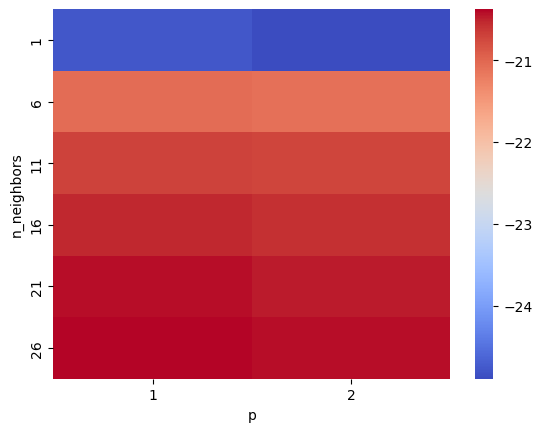

In [28]:
sns.heatmap(
    pd.pivot_table(
        resultats,
        values='score',
        index='n_neighbors',
        columns='p'
    ), cmap='coolwarm'
)
#Amb aquest gràfic es veu clarament que p=1 es igual a p=2, 

<Axes: xlabel='weights', ylabel='n_neighbors'>

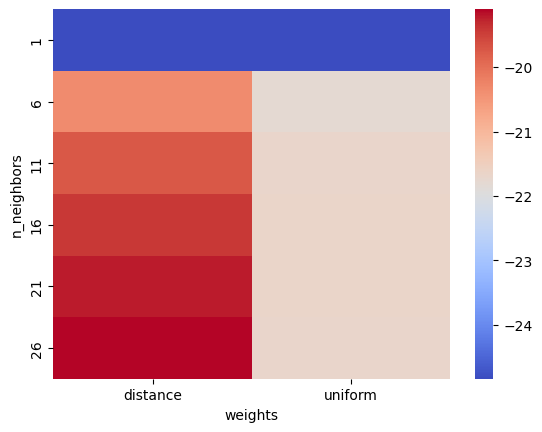

In [29]:
sns.heatmap(
    pd.pivot_table(
        resultats,
        values='score',
        index='n_neighbors',
        columns='weights'
    ), cmap='coolwarm'
)
#distance és millor quasi sempre que uniform, fixarem a distance

<Axes: xlabel='p', ylabel='n_neighbors'>

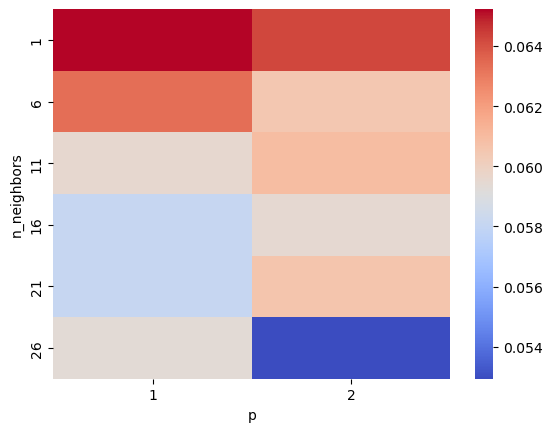

In [30]:
sns.heatmap(
    pd.pivot_table(
        resultats,
        values='mean_fit_time',
        index='n_neighbors',
        columns='p'
    ), cmap='coolwarm'
)
#Ho podem obviar

In [31]:
grid_search.best_params_
#hem explorat hiperparàmetres, temps d'execució, i decidit:
#hem de provar al voltant de n_neighbors millor
#fixarem p=1 (es lijerament superior)
#fixarem weights='distance' (també sol anar millor a aquest problema)

{'regressor__n_neighbors': np.int64(26),
 'regressor__p': 1,
 'regressor__weights': 'distance'}

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

parameters = {
    'regressor__n_neighbors': np.arange(20, 51, 2), #se quedo con el mayor le damos valores mas altos para que pruebe
    'regressor__p': [1],
    'regressor__weights': ['distance'] 
}

preprocessor = StandardScaler()
pipe = Pipeline(steps=[
    ('regressor', KNeighborsRegressor())
])

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv= 5, #StratifiedKFold(n_splits=5, shuffle=True, random_state=42), #Estratificam si que tenim poques rows de la classe minoritaria (30...)
                                                                    #hem posat shuffle i random_state per tenir tots el mateix resultat, sinó 
                                                                    #basta amb n_splits=x
    scoring='neg_root_mean_squared_error',  #accuracy no puede ser aqui es para classifier 
                                            # ej el código pregunta: ¿Es 74.9999 IDÉNTICO a 75.00?
                                            # Respuesta: NO.
                                            # Resultado: 0% de acierto.
    n_jobs=-1, #tots els nuclis
    verbose=2
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor__n_neighbors': array([20, 22..., 46, 48, 50]), 'regressor__p': [1], 'regressor__weights': ['distance']}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(50)


In [33]:
grid_search.best_score_

np.float64(-18.770292190363783)

In [34]:
grid_search.best_params_

{'regressor__n_neighbors': np.int64(50),
 'regressor__p': 1,
 'regressor__weights': 'distance'}

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold

parameters = {
    'regressor__n_neighbors': np.arange(40, 100, 2), #se quedo con el mayor le damos valores mas altos para que pruebe
    'regressor__p': [1],
    'regressor__weights': ['distance'] 
}

preprocessor = StandardScaler()
pipe = Pipeline(steps=[
    ('regressor', KNeighborsRegressor())
])

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv= 5, #StratifiedKFold(n_splits=5, shuffle=True, random_state=42), #Estratificam si que tenim poques rows de la classe minoritaria (30...)
                                                                    #hem posat shuffle i random_state per tenir tots el mateix resultat, sinó 
                                                                    #basta amb n_splits=x
    scoring='neg_root_mean_squared_error',  #accuracy no puede ser aqui es para classifier 
                                            # ej el código pregunta: ¿Es 74.9999 IDÉNTICO a 75.00?
                                            # Respuesta: NO.
                                            # Resultado: 0% de acierto.
    n_jobs=-1, #tots els nuclis
    verbose=2
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regressor__n_neighbors': array([40, 42..., 94, 96, 98]), 'regressor__p': [1], 'regressor__weights': ['distance']}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(98)


In [43]:
grid_search.best_score_

np.float64(-18.024143238254524)

In [44]:
grid_search.best_params_ # ya se quedo con el 98 y no con el 100 aun asi el cambio solo mejoro unas decimas 

{'regressor__n_neighbors': np.int64(98),
 'regressor__p': 1,
 'regressor__weights': 'distance'}

In [45]:
grid_search.cv_results_['mean_test_score']

array([-18.22055735, -18.20036207, -18.17206195, -18.16261805,
       -18.15295028, -18.13893245, -18.12414734, -18.11586465,
       -18.10960051, -18.10362827, -18.10160237, -18.09206893,
       -18.08845769, -18.07825658, -18.07290225, -18.06622837,
       -18.05986416, -18.05465639, -18.04498149, -18.04162876,
       -18.0387446 , -18.035888  , -18.03110315, -18.02772124,
       -18.02827076, -18.02921436, -18.0297089 , -18.03131746,
       -18.02921422, -18.02414324])

In [46]:
#model ajustat.
#avaluar contra test
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred = grid_search.predict(X_test)

grid_search_kneighbors_regresor = grid_search

print(f'MAE: {mean_absolute_error(y_test, y_pred)} cm')
print(f'MSE: {mean_squared_error(y_test, y_pred)} cm^2')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)} cm')

MAE: 11.347758525845885 cm
MSE: 312.3774006900185 cm^2
RMSE: 17.674201557355243 cm


1. Quina ha estat la cerca coarse?
S'ha realitzat una primera exploració general per determinar l'ordre de magnitud dels hiperparàmetres. S'ha provat n_neighbors en un rang de l'1 al 30 amb salts de 5 (np.arange(1, 31, 5)), combinant-ho amb les mètriques de distància (p=1, p=2) i els pesos (uniform, distance).

2. Quins resultats has obtingut?
La millor combinació ha estat {'n_neighbors': 26, 'p': 1, 'weights': 'distance'}.
El resultat més rellevant és que el valor òptim de veïns (26) coincideix amb el límit superior de l'interval provat, indicant que el model encara no ha trobat el seu sostre de rendiment ("Efecte Vora").

3. Com has decidit l’interval de la cerca refinada?
Atesa la saturació al límit superior (26), l'estratègia consisteix a ampliar el rang cap a valors més alts (per exemple, fins a 50 o 60) per trobar l'òptim real. S'han fixat p=1 i weights='distance' (ja decidits) i s'ha reduït el "pas" de cerca (de 5 a 2) per guanyar precisió en la zona crítica.

## DecisionTreeRegressor

In [49]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

In [51]:
parameters = {
}
pipe = Pipeline(steps=[
    ('regressor', DecisionTreeRegressor()) #No requereix de preprocessador
])
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    scoring='neg_root_mean_squared_error', #recall normal no funciona para regresor
    n_jobs=-1,
    cv=StratifiedKFold(5),
    verbose=2
)
grid_search.fit(X_train, y_train)    

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,{}
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [52]:
grid_search.best_score_

np.float64(-24.35114984161649)

In [50]:
 np.arange(2, 300, 10)

In [56]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
parameters = {
    'regresor__max_depth':  np.arange(2, 50, 5),# primera busqueda mas amplia luego vamos afinando
    'regresor__max_leaf_nodes': np.arange(2, 300, 10),
    'regresor__min_samples_leaf': np.arange(2, 50, 5),
    #'regresor__class_weight': ['balanced'] #esta clase es para classifier
}
pipe = Pipeline(steps=[
    ('regresor', DecisionTreeRegressor()) #No requereix de preprocessador
])
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    scoring='neg_root_mean_squared_error', #recall normal no funciona para regresor
    n_jobs=-1,
    cv=5, #StratifiedKFold(5), #esto es para classifier
    verbose=2
)
grid_search.fit(X_train, y_train)    

Fitting 5 folds for each of 3000 candidates, totalling 15000 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regresor__max_depth': array([ 2, 7..., 37, 42, 47]), 'regresor__max_leaf_nodes': array([ 2, ...72, 282, 292]), 'regresor__min_samples_leaf': array([ 2, 7..., 37, 42, 47])}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [57]:
grid_search.best_score_

np.float64(-20.689240445450565)

In [58]:
grid_search.best_params_

{'regresor__max_depth': np.int64(32),
 'regresor__max_leaf_nodes': np.int64(142),
 'regresor__min_samples_leaf': np.int64(7)}

In [127]:
grid_search.cv_results_['mean_test_score'] #hi ha més de 8k candidatsº

array([-21.61171799, -21.61171799, -21.61171799, ..., -20.88394222,
       -20.87919272, -20.87246745], shape=(3000,))

In [128]:
resultats = pd.DataFrame(grid_search.cv_results_['mean_test_score'], columns=['score'])
resultats['max_depth'] = grid_search.cv_results_['param_regresor__max_depth']
resultats['max_leaf_nodes'] = grid_search.cv_results_['param_regresor__max_leaf_nodes']
resultats['min_samples_leaf'] = grid_search.cv_results_['param_regresor__min_samples_leaf']
resultats

,score,max_depth,max_leaf_nodes,min_samples_leaf
0,-21.611718,2,2,2
1,-21.611718,2,2,7
2,-21.611718,2,2,12
3,-21.611718,2,2,17
4,-21.611718,2,2,22
...,...,...,...,...
2995,-20.899144,47,292,27
2996,-20.964974,47,292,32
2997,-20.883942,47,292,37
2998,-20.879193,47,292,42


<Axes: xlabel='max_leaf_nodes', ylabel='max_depth'>

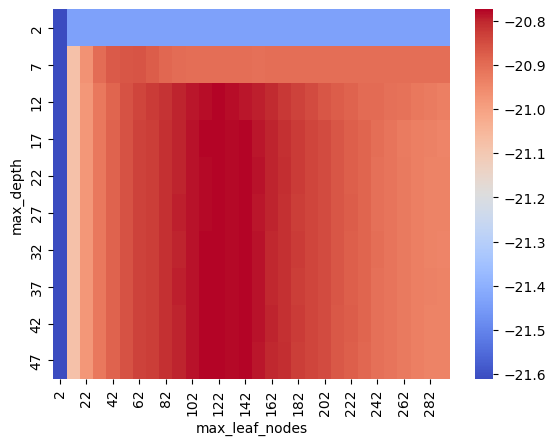

In [129]:
sns.heatmap(
    pd.pivot_table(resultats,
                   values='score',
                   index='max_depth',
                   columns='max_leaf_nodes'),
    cmap='coolwarm'
) # se ve que la zona de 120 140 de max leaf nodes es la buena

<Axes: xlabel='min_samples_leaf', ylabel='max_depth'>

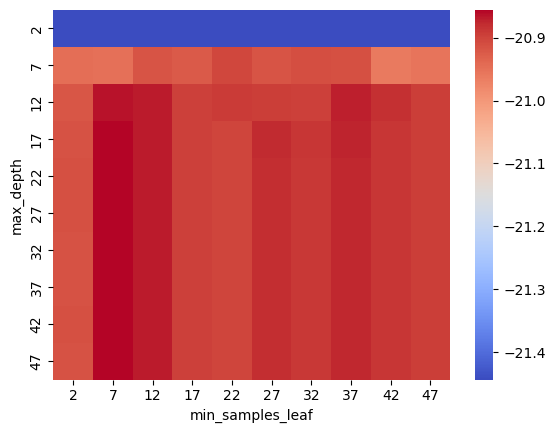

In [130]:
sns.heatmap(
    pd.pivot_table(resultats,
                   values='score',
                   index='max_depth',
                   columns='min_samples_leaf'),
    cmap='coolwarm'
) # se ve que la zona de 7 de min samples leaf es la buena

<Axes: xlabel='min_samples_leaf', ylabel='max_leaf_nodes'>

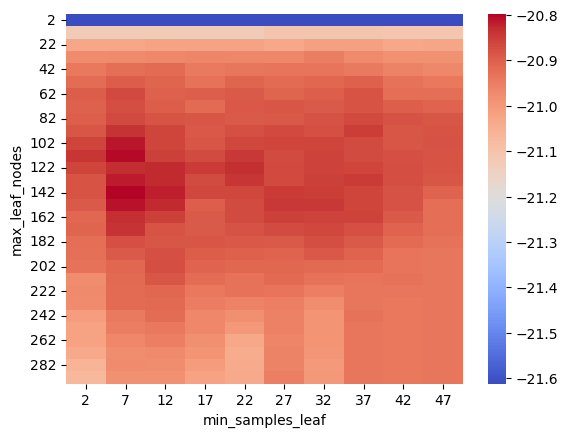

In [131]:
sns.heatmap(
    pd.pivot_table(resultats,
                   values='score',
                   index='max_leaf_nodes',
                   columns='min_samples_leaf'),
    cmap='coolwarm'
) # se ve que la zona de 7 de min samples leaf y el rango de 100 a 150 de max leaf nodes es la buena

In [132]:
grid_search.best_estimator_['regresor'].feature_importances_

array([0.09693147, 0.05158821, 0.14851933, 0.08365113, 0.17042218,
       0.01881573, 0.0587273 , 0.10826262, 0.        , 0.0514175 ,
       0.06680925, 0.00321016, 0.14164511])

In [ ]:
# No aplica, esto es para classificacion
# 
# from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
# from sklearn.metrics import classification_report
# 
# y_pred = grid_search.predict(X_test)
# print(classification_report(y_test,y_pred))
# cm = confusion_matrix(y_test, y_pred, labels=grid_search.best_estimator_['classifier'].classes_)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm,
#                                display_labels=grid_search.best_estimator_['classifier'].classes_)
# disp.plot()

In [ ]:
{'regresor__max_depth': np.int64(47),
 'regresor__max_leaf_nodes': np.int64(142),
 'regresor__min_samples_leaf': np.int64(7)}

In [111]:
 np.arange(5, 15, 1)

array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [140]:
parameters = {
    'regresor__max_depth':  np.arange(40, 56, 1), 
    'regresor__max_leaf_nodes':  np.arange(130, 151, 2), 
    'regresor__min_samples_leaf':  np.arange(5, 16, 1)
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    cv=5,
    verbose=1
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1936 candidates, totalling 9680 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regresor__max_depth': array([40, 41..., 53, 54, 55]), 'regresor__max_leaf_nodes': array([130, 1...46, 148, 150]), 'regresor__min_samples_leaf': array([ 5, 6..., 13, 14, 15])}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [142]:
grid_search.best_score_

np.float64(-20.626891710218867)

In [143]:
grid_search.best_params_

{'regresor__max_depth': np.int64(42),
 'regresor__max_leaf_nodes': np.int64(140),
 'regresor__min_samples_leaf': np.int64(9)}

In [144]:
resultats = pd.DataFrame(grid_search.cv_results_['mean_test_score'], columns=['score'])
resultats['max_depth'] = grid_search.cv_results_['param_regresor__max_depth']
resultats['max_leaf_nodes'] = grid_search.cv_results_['param_regresor__max_leaf_nodes']
resultats['min_samples_leaf'] = grid_search.cv_results_['param_regresor__min_samples_leaf']
resultats

,score,max_depth,max_leaf_nodes,min_samples_leaf
0,-20.787809,40,130,5
1,-20.762972,40,130,6
2,-20.721076,40,130,7
3,-20.691431,40,130,8
4,-20.683533,40,130,9
...,...,...,...,...
1931,-20.685111,55,150,11
1932,-20.733913,55,150,12
1933,-20.764808,55,150,13
1934,-20.758015,55,150,14


<Axes: xlabel='max_leaf_nodes', ylabel='max_depth'>

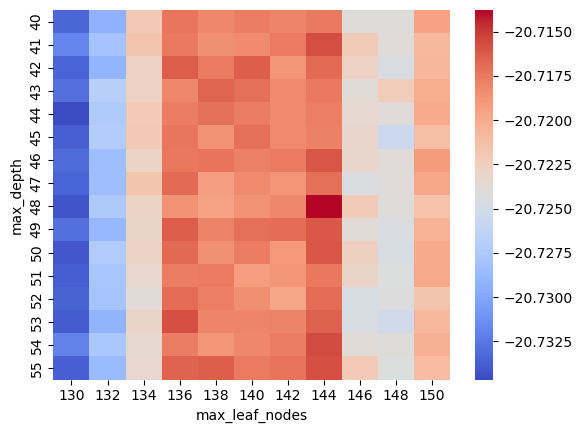

In [145]:
sns.heatmap(
    pd.pivot_table(resultats,
                   values='score',
                   index='max_depth',
                   columns='max_leaf_nodes'),
    cmap='coolwarm'
) # se ve que la zona de 144 de max leaf nodes es la buena

<Axes: xlabel='min_samples_leaf', ylabel='max_depth'>

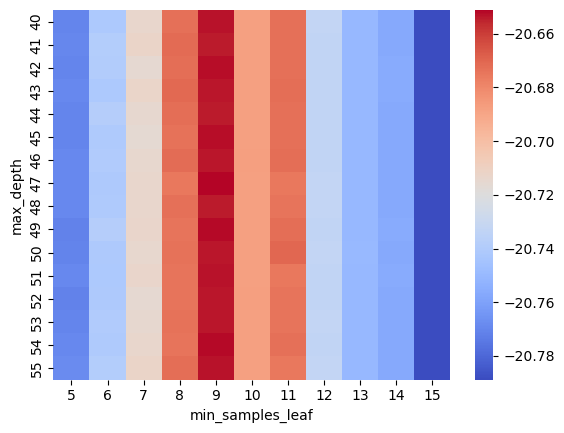

In [146]:
sns.heatmap(
    pd.pivot_table(resultats,
                   values='score',
                   index='max_depth',
                   columns='min_samples_leaf'),
    cmap='coolwarm'
)# se ve que la zona de 9 de min sample leaf es la buena

<Axes: xlabel='min_samples_leaf', ylabel='max_leaf_nodes'>

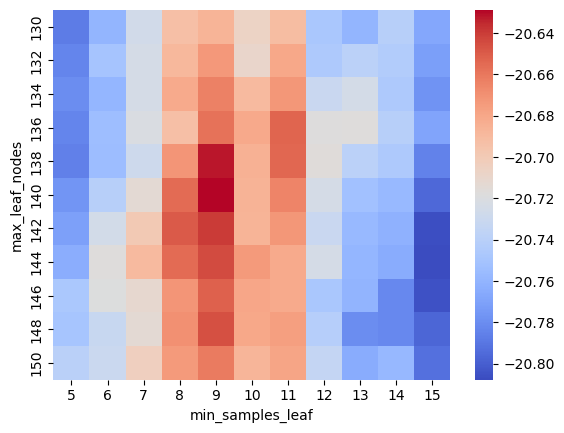

In [147]:
sns.heatmap(
    pd.pivot_table(resultats,
                   values='score',
                   index='max_leaf_nodes',
                   columns='min_samples_leaf'),
    cmap='coolwarm'
) # se ve que la zona de 9 de min sample leaf con el max leaf nodes de 140 a 138 es la buena

{'regresor__max_depth': np.int64(43),
 'regresor__max_leaf_nodes': np.int64(140),
 'regresor__min_samples_leaf': np.int64(9)}

In [148]:
np.arange(8,11,1)

array([ 8,  9, 10])

In [51]:
parameters = {
    'regresor__max_depth':  np.arange(43,46,1), 
    'regresor__max_leaf_nodes':  np.arange(138,143,1), 
    'regresor__min_samples_leaf':  np.arange(8,11,1)
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    cv=5,
    verbose=1
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


,estimator,Pipeline(step...Regressor())])
,param_grid,"{'regresor__max_depth': array([43, 44, 45]), 'regresor__max_leaf_nodes': array([138, 1...40, 141, 142]), 'regresor__min_samples_leaf': array([ 8, 9, 10])}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [52]:
grid_search.best_score_

np.float64(-20.624581051615824)

In [151]:
grid_search.best_params_

{'regresor__max_depth': np.int64(44),
 'regresor__max_leaf_nodes': np.int64(139),
 'regresor__min_samples_leaf': np.int64(9)}

In [152]:
resultats = pd.DataFrame(grid_search.cv_results_['mean_test_score'], columns=['score'])
resultats['max_depth'] = grid_search.cv_results_['param_regresor__max_depth']
resultats['max_leaf_nodes'] = grid_search.cv_results_['param_regresor__max_leaf_nodes']
resultats['min_samples_leaf'] = grid_search.cv_results_['param_regresor__min_samples_leaf']
resultats

,score,max_depth,max_leaf_nodes,min_samples_leaf
0,-20.673090,43,138,8
1,-20.634536,43,138,9
2,-20.684577,43,138,10
3,-20.664427,43,139,8
4,-20.631514,43,139,9
5,-20.682666,43,139,10
6,-20.654943,43,140,8
7,-20.626892,43,140,9
8,-20.685912,43,140,10
9,-20.648656,43,141,8


<Axes: xlabel='max_leaf_nodes', ylabel='max_depth'>

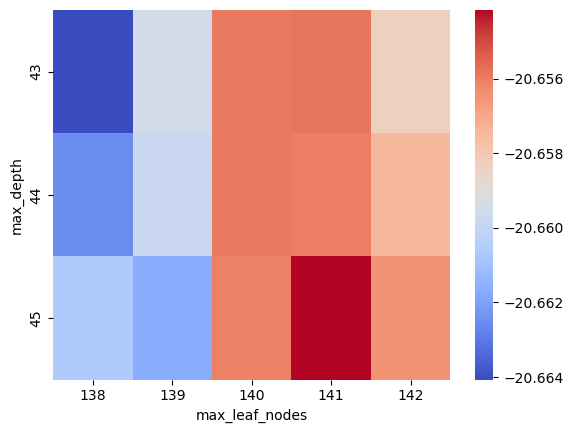

In [153]:
sns.heatmap(
    pd.pivot_table(resultats,
                   values='score',
                   index='max_depth',
                   columns='max_leaf_nodes'),
    cmap='coolwarm'
) # se ve que la zona de 141 de max leaf nodes es la buena

<Axes: xlabel='min_samples_leaf', ylabel='max_depth'>

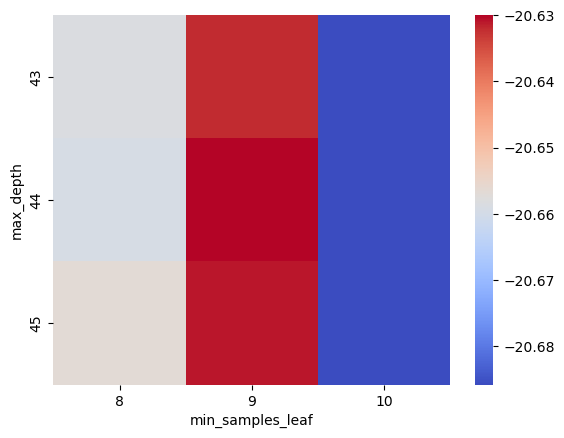

In [154]:
sns.heatmap(
    pd.pivot_table(resultats,
                   values='score',
                   index='max_depth',
                   columns='min_samples_leaf'),
    cmap='coolwarm'
)# se ve que la zona de 9 de min sample leaf es la buena

<Axes: xlabel='min_samples_leaf', ylabel='max_leaf_nodes'>

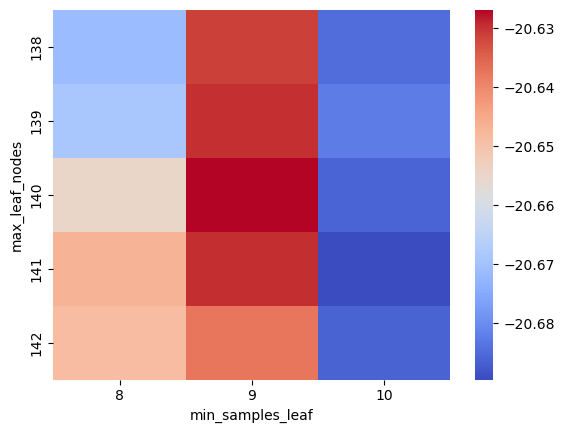

In [155]:
sns.heatmap(
    pd.pivot_table(resultats,
                   values='score',
                   index='max_leaf_nodes',
                   columns='min_samples_leaf'),
    cmap='coolwarm'
) # se ve que la zona de 9 de min sample leaf con el max leaf nodes de 140 es la buena

In [53]:
#model ajustat.
#avaluar contra test
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred = grid_search.predict(X_test)

grid_search_decision_tree_regresor = grid_search

print(f'MAE: {mean_absolute_error(y_test, y_pred)} cm')
print(f'MSE: {mean_squared_error(y_test, y_pred)} cm^2')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)} cm')

MAE: 16.36708151579729 cm
MSE: 431.7753409707966 cm^2
RMSE: 20.77920453171383 cm


## RandomForestRegressor

In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [57]:
pipe = Pipeline(steps=[
    ('regresor', RandomForestRegressor(random_state=42, n_jobs=-1)) 
])

parameters = {
    'regresor__n_estimators': [50, 100, 200],
    'regresor__max_depth': [2, 5, 10,20,], 
    'regresor__max_features': [0.33],#'sqrt', classifier
    'regresor__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    scoring='neg_root_mean_squared_error',
    cv=5,       
    n_jobs=-1,  
    verbose=2  
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'regresor__max_depth': [2, 5, ...], 'regresor__max_features': [0.33], 'regresor__min_samples_leaf': [1, 2, ...], 'regresor__n_estimators': [50, 100, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [23]:
grid_search_rf.best_score_

np.float64(-17.527755527484228)

In [24]:
grid_search_rf.best_params_

{'regresor__max_depth': 20,
 'regresor__max_features': 0.33,
 'regresor__min_samples_leaf': 1,
 'regresor__n_estimators': 200}

In [58]:
#model ajustat.
#avaluar contra test
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred = grid_search.predict(X_test)

grid_search_random_forest_regressor = grid_search

print(f'MAE: {mean_absolute_error(y_test, y_pred)} cm')
print(f'MSE: {mean_squared_error(y_test, y_pred)} cm^2')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)} cm')

MAE: 12.588276234363777 cm
MSE: 296.9948389318879 cm^2
RMSE: 17.233538201190374 cm


## SVR

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVR

In [ ]:
parameters = {}

pipe = Pipeline(steps=[
    ('regressor', LinearSVR())
])

grid_search = GridSearchCV(
    estimator=pipe, 
    param_grid=parameters,
    cv=5, # este caso es si nos importa la serie temporal de las variables TimeSeriesSplit(n_splits=24), 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 24 folds for each of 1 candidates, totalling 24 fits


C:\Users\EIABD\miniconda3\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,estimator,Pipeline(step...LinearSVR())])
,param_grid,{}
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,epsilon,0.0


In [72]:
grid_search.best_score_

np.float64(-22.168866925715772)

In [73]:
y_train.mean()

np.float64(53.06099017786037)

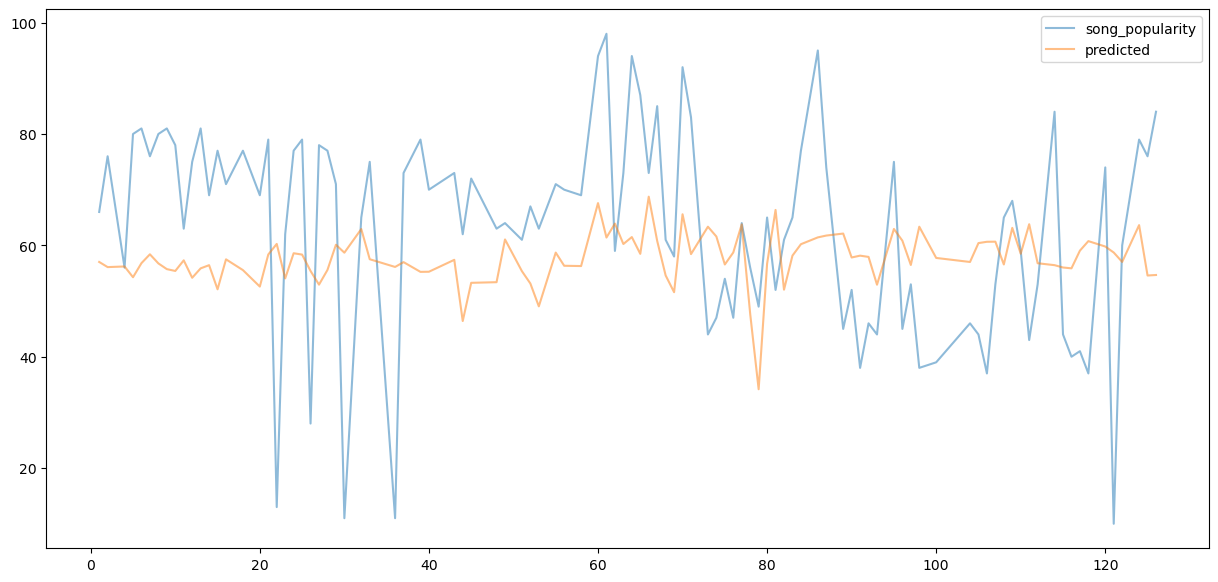

In [74]:
predictions = pd.DataFrame(y_train)

predictions['predicted'] = grid_search.predict(X_train)

predictions = predictions.sort_index()

predictions.iloc[:100].plot(alpha=0.5, figsize=(15,7))
plt.show()

In [79]:
np.logspace(-6, 6, 7)

array([1.e-06, 1.e-04, 1.e-02, 1.e+00, 1.e+02, 1.e+04, 1.e+06])

In [60]:
parameters = {
    'regressor__epsilon': np.logspace(-6, 6, 7),
    'regressor__C': np.logspace(-6, 6, 7)
}

pipe = Pipeline(steps=[
    ('regressor', LinearSVR())
])

grid_search = GridSearchCV(
    estimator=pipe, 
    param_grid=parameters,
    cv=TimeSeriesSplit(n_splits=24), 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 24 folds for each of 49 candidates, totalling 1176 fits


C:\Users\EIABD\miniconda3\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,estimator,Pipeline(step...LinearSVR())])
,param_grid,"{'regressor__C': array([1.e-06...e+04, 1.e+06]), 'regressor__epsilon': array([1.e-06...e+04, 1.e+06])}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,epsilon,np.float64(1e-06)


In [61]:
grid_search.best_params_

{'regressor__C': np.float64(1.0), 'regressor__epsilon': np.float64(1e-06)}

In [62]:
grid_search.best_score_

np.float64(-22.14773771975001)

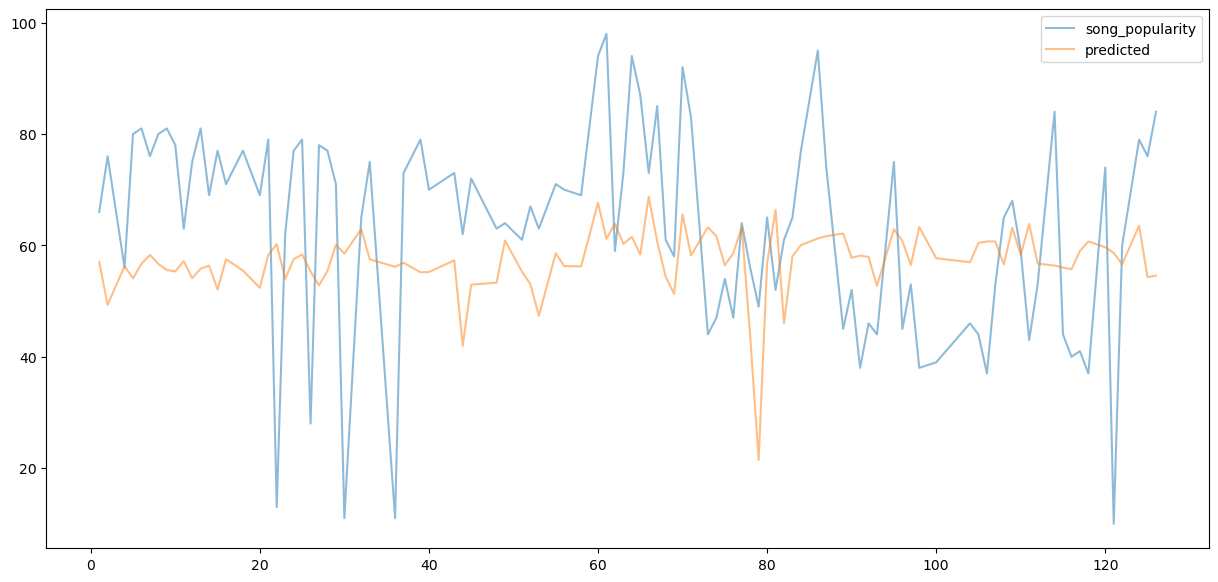

In [90]:
predictions = pd.DataFrame(y_train)

predictions['predicted'] = grid_search.predict(X_train)

predictions = predictions.sort_index()

predictions.iloc[:100].plot(alpha=0.5, figsize=(15,7))
plt.show()

In [91]:
resultats = pd.DataFrame(grid_search.cv_results_['mean_test_score'], columns=['score'])
resultats['C'] = grid_search.cv_results_['param_regressor__C']
resultats['epsilon'] = grid_search.cv_results_['param_regressor__epsilon']
resultats

,score,C,epsilon
0,-55.783945,0.000001,0.000001
1,-55.784170,0.000001,0.000100
2,-55.784333,0.000001,0.010000
3,-55.784867,0.000001,1.000000
4,-57.368912,0.000001,100.000000
5,-57.368912,0.000001,10000.000000
6,-57.368912,0.000001,1000000.000000
7,-54.413914,0.000100,0.000001
8,-54.413013,0.000100,0.000100
9,-54.413783,0.000100,0.010000


array([  10.,  100., 1000.])

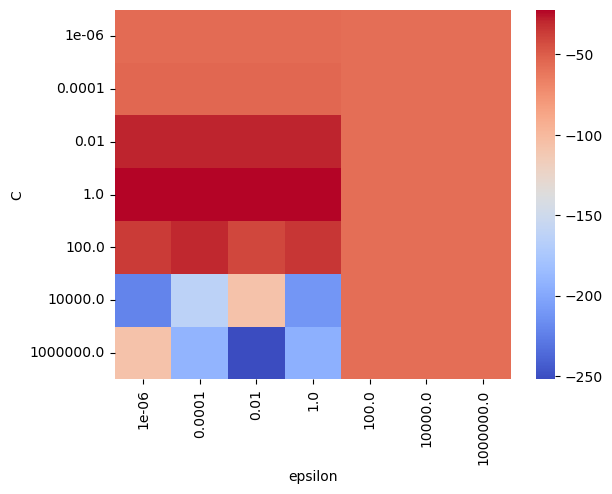

In [93]:
import seaborn as sns
sns.heatmap(
    pd.pivot_table(
        resultats,
        values='score',
        index='C',
        columns='epsilon'
    ), cmap='coolwarm'
)


In [95]:
np.logspace(0.01, 100, 50),

(array([1.02329299e+000, 1.12360133e+002, 1.23374240e+004, 1.35468005e+006,
        1.48747262e+008, 1.63328218e+010, 1.79338474e+012, 1.96918135e+014,
        2.16221044e+016, 2.37416120e+018, 2.60688846e+020, 2.86242881e+022,
        3.14301851e+024, 3.45111303e+026, 3.78940853e+028, 4.16086546e+030,
        4.56873447e+032, 5.01658486e+034, 5.50833580e+036, 6.04829065e+038,
        6.64117460e+040, 7.29217601e+042, 8.00699187e+044, 8.79187759e+046,
        9.65370176e+048, 1.06000063e+051, 1.16390723e+053, 1.27799929e+055,
        1.40327522e+057, 1.54083134e+059, 1.69187139e+061, 1.85771716e+063,
        2.03981996e+065, 2.23977340e+067, 2.45932728e+069, 2.70040294e+071,
        2.96511005e+073, 3.25576508e+075, 3.57491159e+077, 3.92534245e+079,
        4.31012431e+081, 4.73262443e+083, 5.19654013e+085, 5.70593120e+087,
        6.26525534e+089, 6.87940726e+091, 7.55376145e+093, 8.29421923e+095,
        9.10726042e+097, 1.00000000e+100]),)

In [100]:
np.logspace(0.000001, 0.1, 20)

array([1.0000023 , 1.01219481, 1.02453597, 1.0370276 , 1.04967154,
       1.06246963, 1.07542377, 1.08853585, 1.1018078 , 1.11524157,
       1.12883912, 1.14260247, 1.15653362, 1.17063463, 1.18490757,
       1.19935453, 1.21397763, 1.22877903, 1.24376089, 1.25892541])

In [63]:
import numpy as np

parameters = {
    'regressor__C': [0.1, 0.5, 1, 2, 5, 10, 20, 50],
    'regressor__epsilon': [0, 0.05, 0.1, 0.2, 0.5, 1]
}

pipe = Pipeline(steps=[
    ('preprocessor', StandardScaler()),
    ('regressor', LinearSVR())
])

grid_search = GridSearchCV(
    estimator=pipe, 
    param_grid=parameters,
    cv=TimeSeriesSplit(n_splits=24), #horitzó temporal de mes
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 24 folds for each of 48 candidates, totalling 1152 fits


,estimator,Pipeline(step...LinearSVR())])
,param_grid,"{'regressor__C': [0.1, 0.5, ...], 'regressor__epsilon': [0, 0.05, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [64]:
grid_search.best_params_

{'regressor__C': 0.5, 'regressor__epsilon': 1}

In [103]:
grid_search.best_score_

np.float64(-21.58088354416959)

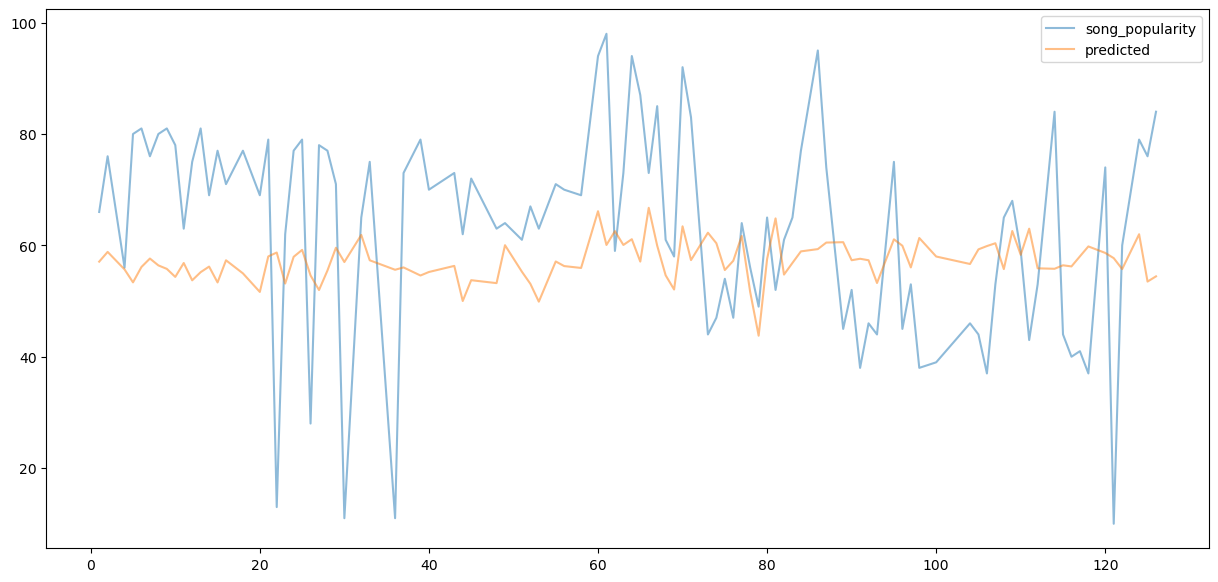

In [104]:
predictions = pd.DataFrame(y_train)

predictions['predicted'] = grid_search.predict(X_train)

predictions = predictions.sort_index()

predictions.iloc[:100].plot(alpha=0.5, figsize=(15,7))
plt.show()

<Axes: xlabel='epsilon', ylabel='C'>

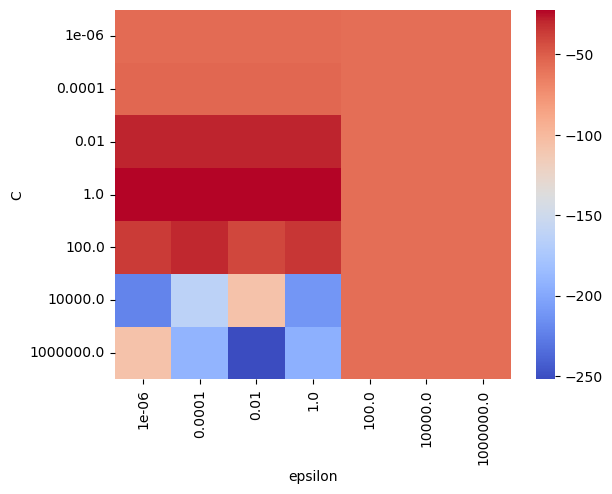

In [105]:
import seaborn as sns
sns.heatmap(
    pd.pivot_table(
        resultats,
        values='score',
        index='C',
        columns='epsilon'
    ), cmap='coolwarm'
)


In [65]:
#model ajustat.
#avaluar contra test
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

y_pred = grid_search.predict(X_test)

grid_search_linear_svr = grid_search

print(f'MAE: {mean_absolute_error(y_test, y_pred)} cm')
print(f'MSE: {mean_squared_error(y_test, y_pred)} cm^2')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)} cm')

MAE: 16.919538508380747 cm
MSE: 471.4689147636353 cm^2
RMSE: 21.71333495259619 cm


## StackingRegressor

In [66]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

best_lr = grid_search_linear_regresion.best_estimator_
best_kr = grid_search_kernel_ridge.best_estimator_
best_knr = grid_search_kneighbors_regresor.best_estimator_
best_dtr = grid_search_decision_tree_regresor.best_estimator_
best_rfr = grid_search_random_forest_regressor.best_estimator_
best_svr = grid_search_linear_svr.best_estimator_

estimators = [
    ('linear_regresion', best_lr),
    ('kernel_ridge', best_kr),
    ('kneighbors_regresor', best_knr),
    ('decision_tree_regresor', best_dtr),
    ('random_forest_regressor', best_rfr),
    ('best_svr', best_svr)
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    cv=5,     
    n_jobs=-1,
    passthrough=False 
)

stacking_model.fit(X_train, y_train)

,estimators,"[('linear_regresion', ...), ('kernel_ridge', ...), ...]"
,final_estimator,LinearRegression()
,cv,5
,n_jobs,-1
,passthrough,False
,verbose,0
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True


In [86]:
import pandas as pd

meta_model = stacking_model.final_estimator_

noms_models = [nom for nom, _ in estimators]
pesos = meta_model.coef_

df_coef = pd.DataFrame({
    'Model Base': noms_models,
    'Pes (Coeficient)': pesos
})

print(f"Intercept (Terme independent): {meta_model.intercept_:.4f}\n")
print("Pesos atorgats a cada model (de més a menys):")
print(df_coef.sort_values(by='Pes (Coeficient)', ascending=False).to_string(index=False))

Intercept (Terme independent): -0.5646

Pesos atorgats a cada model (de més a menys):
             Model Base  Pes (Coeficient)
random_forest_regressor          0.630727
    kneighbors_regresor          0.496273
       linear_regresion          0.106665
 decision_tree_regresor         -0.001725
               best_svr         -0.060149
           kernel_ridge         -0.208140


In [69]:
y_pred_test = stacking_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"RMSE Final en Test (Stacking): {rmse_test}")

RMSE Final en Test (Stacking): 16.87928968976404


# Interpretació del model de Stacking

Analitza el meta-model lineal:

1. Quin model base rep més pes?
El Random Forest, amb un pes de 0.63. El meta-model el considera l'expert principal del grup.

3. Hi ha algun model amb pes molt baix?
Sí, el Decision Tree està pràcticament a zero (-0.001). Té molta lògica: com que el Random Forest ja és un "bosc" de molts arbres, un arbre sol no aporta cap informació nova. L'SVR també s'ignora bastant (-0.06).

4. Hi ha algun coeficient negatiu? Què podria significar?
Sí, el Kernel Ridge destaca amb un -0.20. En un stacking, els pesos negatius s'usen per corregir. Si els altres models tendeixen a "passar-se de frenada" i predir valors massa alts, el meta-model fa servir el Kernel Ridge per restar una mica i equilibrar el resultat.

5. L'stacking millora realment respecte al millor model individual?
Sí, L'error RMSE baixa de 17.23 a 16.88 amb Stacking

6. El meta-model sembla confiar en un únic model o combina diversos?
Es fia principalment d'un tàndem de dos: el Random Forest (0.63) i el K-Neighbors (0.49). Entre ells dos prenen gairebé tota la decisió.

7. Interpreta si hi ha complementarietat entre models.
Hi ha molt bona complementarietat. El meta-model ha donat el poder a dos models que pensen de maneres oposades: el Random Forest crea regles lògiques, i el K-Neighbors busca cançons similars per distància. Com que aprenen de formes tan diferents, cobreixen els punts cecs l'un de l'altre.

# Fase final — Anàlisi crítica

1. Quin model generalitza millor?
L'Stacking Regressor. Al combinar els punts forts de tots, ha aconseguit l'error més baix en test (16.88). És el que millor s'adapta a dades noves.

2. Quin model mostra més variància?
L'Arbre de Decisió. Tendeix a memoritzar-ho tot (overfitting). Per això mateix, el meta model l'ha ignorat (pes de -0.001) i ha preferit el Random Forest, que és molt més estable.

3. El problema sembla principalment lineal o no lineal?
No lineal. Els models que millor han funcionat (Random Forest i K-Neighbors) no són lineals. La popularitat d'una cançó és massa complexa per dibuixar-la amb una línia recta.

4. És realista predir la popularitat només amb característiques d’àudio?
Gens. Una cançó no triomfa només per tenir un bon ritme. Depèn de si l'artista ja és famós, de la campanya de màrqueting que tingui darrere o de si es fa viral a xarxes.

5. Limitacions del dataset.
Li falta el context decisiu: no sabem qui canta, quants diners s'han invertit en promoció ni si està a les millors playlists de Spotify. A més, la popularitat canvia cada dia, i aquestes dades només mostren un moment concret.
